In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import time
from smbus2 import SMBus,i2c_msg
import MCP342x
from scservo_sdk import *                    # Uses SCServo SDK library
import MCP342x
import logging
from pts_iterator import pts_iterator

logging.basicConfig(
    level=logging.INFO,  # Set the logging level to DEBUG
    # level= logging.DEBUG,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

from servodriver import Servoset
from servo_util import create_zigzag_X, format_para,a2p,r2nd,r2nr,ndmodr,nrselr,nrmodr,nraddr
from spiral import SpiralPath
from scipy.optimize import differential_evolution
from fit_gaussian import gaussian_2d,fit_and_plot,fit_gaussian_2d
from motor_2d_scan import motor_2d_scan
from servo_const import A_X_XDOT_MASK,A_Y_YDOT_MASK,A_X_Y_MASK,A_XDOT_YDOT_MASK,A_POS_ALL_MASK,B_X_XDOT_MASK,B_Y_YDOT_MASK,B_X_Y_MASK,B_XDOT_YDOT_MASK,B_POS_ALL_MASK,POS_ALL_MASK
from step_optimize import step_optimize
from pd import MCP3424_fiber
MCP3424_fiber.convert_and_read()

0.31875000000000003


0.318375

In [2]:
servos = Servoset(board_id=0,servo_channel_list=[0,1,2,3,4,5,6,7])
servos.torques_enable()
servos.home()

2024-09-20 13:55:01,870 - INFO - The device /dev/ttyUSB0 is not available, try next ...
2024-09-20 13:55:01,884 - INFO - Succeeded to open the port
2024-09-20 13:55:01,897 - INFO - Succeeded to change the baudrate
2024-09-20 13:55:01,902 - INFO - Servo 1x: SCServo acc set!
2024-09-20 13:55:01,907 - INFO - Servo 1x: SCServo speed set!
2024-09-20 13:55:01,912 - INFO - Servo 1x: SCServo acc set!
2024-09-20 13:55:01,917 - INFO - Servo 1x: SCServo speed set!
2024-09-20 13:55:01,926 - INFO - Servo 1y: SCServo acc set!
2024-09-20 13:55:01,931 - INFO - Servo 1y: SCServo speed set!
2024-09-20 13:55:01,937 - INFO - Servo 1y: SCServo acc set!
2024-09-20 13:55:01,943 - INFO - Servo 1y: SCServo speed set!
2024-09-20 13:55:01,952 - INFO - Servo 2x: SCServo acc set!
2024-09-20 13:55:01,957 - INFO - Servo 2x: SCServo speed set!
2024-09-20 13:55:01,962 - INFO - Servo 2x: SCServo acc set!
2024-09-20 13:55:01,967 - INFO - Servo 2x: SCServo speed set!
2024-09-20 13:55:01,976 - INFO - Servo 2y: SCServo acc

In [3]:
def callback_func(para,
                  pos_mask,
                  zero=None,
                  jac=None,
                  jac_master_mask=None):
    # start from zero point, step para
    if zero is None:
        zero = np.zeros(len(pos_mask))
    para_nr_move = nraddr(zero,para,pos_mask)
    # set slave knobs according to jac
    if jac is not None:
        assert jac_master_mask is not None, "jac_master_mask is not provided"
        dr = r2nr(para,r_mask = pos_mask)
        dr = nrselr(dr,jac_master_mask)
        # print(dr)
        d_slave_r = np.dot(jac,dr)
        # print(d_slave_r)
        jac_slave_mask = 1-np.array(jac_master_mask)
        para_nr_move = nraddr(para_nr_move,d_slave_r,jac_slave_mask)
        # print(para_nr_move)

    #
    goal_position_list  = r2nd(list(para_nr_move))
    # print(goal_position_list)
    servos.set_angle(goal_position_list)
    #
    data_cache = []
    for m in range(2):
        # data = ADS1115_fiber.value
        data = MCP3424_fiber.convert_and_read()
        data_cache.append(data)
    z = float(np.mean(np.array(data)))
    # print(para,z)
    return tuple(para),z

cf0 = lambda para: callback_func(para, pos_mask=POS_ALL_MASK)
cf0([0,0,0,0,0,0,0,0])

((0, 0, 0, 0, 0, 0, 0, 0), 0.3185)

## 2D Scan

In [4]:
jac_pm_30_1 = np.load("/home/rydpiservo/servodata/jac_pm_30_1.npy")
jac_pm_50 = np.load("/home/rydpiservo/servodata/jac_pm_50.npy")
jac_rand_50 = np.load("/home/rydpiservo/servodata/jac_rand_50.npy")
print(jac_pm_30_1)

[[-1.75736653 -0.00543325  1.29643978 -0.25109583]
 [-0.26917322 -1.18683474  0.3181535  -1.10010238]
 [-0.69326715  0.01981146  0.25349958 -0.22117829]
 [ 0.2321258   0.07326801 -0.2947579   0.01416482]]


2024-09-20 13:55:32,190 - INFO - z0: ((0, 0), 0.322625)
100%|██████████| 64/64 [00:19<00:00,  3.34it/s]


0.3205


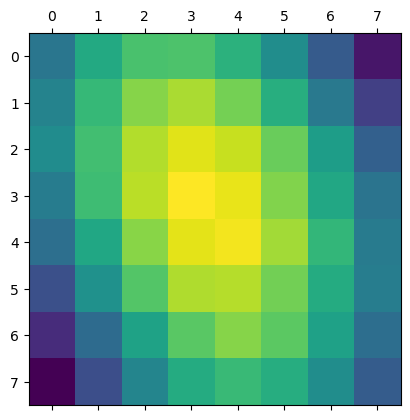

In [6]:
N_pts = 8
SCAN_RANGE = 40
POS_MASK = A_X_Y_MASK
cf = lambda para: callback_func(para, pos_mask=POS_MASK, jac=jac_pm_50, jac_master_mask=A_POS_ALL_MASK)
# cf = lambda para: callback_func(para, pos_mask=POS_MASK)
X,Y,Z = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)

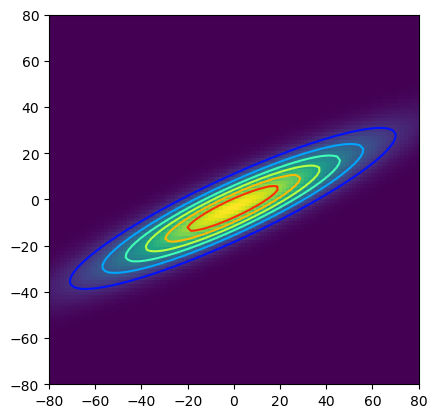

In [10]:
fit_and_plot(X,Y,Z)

In [24]:
def find_max_pos(Z):
    idx = np.argmax(Z)
    idx_i, idx_j = np.unravel_index(idx, Z.shape)
    return idx_i,idx_j
idx_x_max,idx_y_max = find_max_pos(Z)
print(f"Max position: {X[idx_x_max,idx_y_max],Y[idx_x_max,idx_y_max]}")
x_max = X[idx_x_max,idx_y_max]
y_max = Y[idx_x_max,idx_y_max]
px, py = a2p(X[idx_x_max,idx_y_max]), a2p(Y[idx_x_max,idx_y_max])
#
# servos.set_angle([px,a2p(0),py,a2p(0)])
pos_list = r2nd([x_max,y_max],POS_MASK)
servos.set_angle(pos_list)
# print(ADS1115_fiber.value)
print(MCP3424_fiber.convert_and_read())

Max position: (-6.0, 6.0)
0.9948750000000001


## Iterative Spiral Optimization

In [20]:
zero = np.array([0,0,0,0,0,0,0,0],dtype=float)

2024-09-20 10:20:43,323 - INFO - Start optimization with zero = [0. 0. 0. 0. 0. 0. 0. 0.]


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            8     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f= -3.00187D-01    |proj g|=  9.55000D-03

At iterate    1    f= -3.03000D-01    |proj g|=  9.11250D-03

At iterate    2    f= -3.15125D-01    |proj g|=  8.41250D-03

At iterate    3    f= -3.16500D-01    |proj g|=  8.66250D-03
  ys=-5.876E-06  -gs= 3.464E-04 BFGS update SKIPPED


2024-09-20 10:23:12,145 - INFO - Converged position: x_0=-1.74 x_1=-3.07 x_2=-2.63 x_3=-3.23 x_4=-1.16 x_5=-2.18 x_6=-1.66 x_7=-1.91
2024-09-20 10:23:12,146 - INFO - Best point: x_0=-2.99 x_1=-4.20 x_2=-4.94 x_3=1.15 x_4=-3.36 x_5=-2.45 x_6=-3.06 x_7=-2.02; T=0.32525



At iterate    4    f= -3.16125D-01    |proj g|=  8.12500D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    8      4     21      4     1     0   8.125D-03  -3.161D-01
  F = -0.31612499999999999     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH             


2024-09-20 10:23:13,804 - INFO - Best position: x_0=-2.99 x_1=-4.20 x_2=-4.94 x_3=1.15 x_4=-3.36 x_5=-2.45 x_6=-3.06 x_7=-2.02, now I: 0.3253125
2024-09-20 10:23:13,805 - INFO - New Origin set to be x_0=-2.99 x_1=-4.20 x_2=-4.94 x_3=1.15 x_4=-3.36 x_5=-2.45 x_6=-3.06 x_7=-2.02
2024-09-20 10:23:13,806 - INFO - Zero = [-2.99009584 -4.19703685 -4.94470445  1.14882189 -3.35884859 -2.45452894
 -3.05562265 -2.02403744]


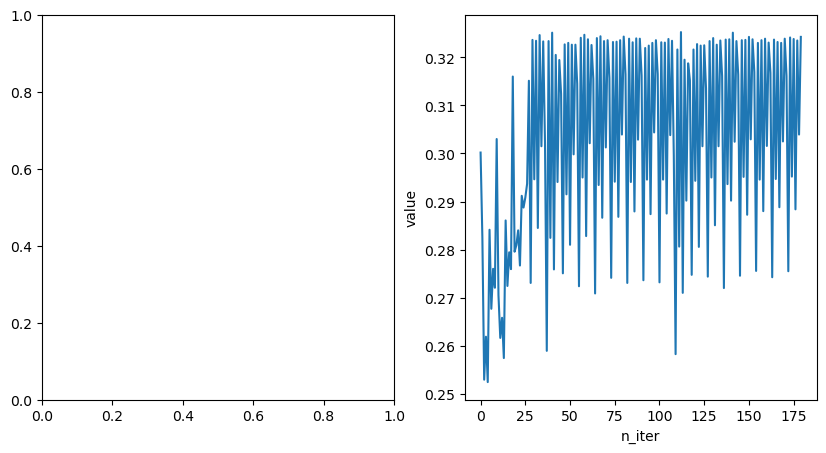

In [17]:
spiral_params = {
    'I_meaningful': 0.01,
    'D': 2,
    'SPIRAL_RESOLUTION': 15,
    'SPIRAL_SPAN': 8,
    'SINGLE_SPIRAL_SPAN': 4,
    'N_LOOPS_BEFORE_RESET_ORIGIN': 0.5,
    'MAX_X0Y0_DISPLACEMENT': 10,
    'COEF_I_RESET_ORIGIN': 1.4,
    'alpha': 0.03,
    'COEF_I_DECAY': 0.995
}
BFGS_params = {"disp": True, "maxiter": 10,  "eps": 5}
logging.getLogger().setLevel(logging.INFO)
#
bounds_single = (-100,100)

def iterative_optimize(pos_mask, method="spiral",zero=None,offset=None,offset_mask=None)->np.ndarray:
    if method == 'L-BFGS-B':
        servos.set_precision(1)
        options = BFGS_params
    elif method == 'spiral':
        servos.set_precision(5)
        options = spiral_params
    #
    N_var = np.sum(pos_mask)
    p0 = np.zeros(N_var)
    bounds = [bounds_single for i in range(N_var)]
    cf = lambda x: callback_func(x,pos_mask,zero=zero,offset=offset,offset_mask=offset_mask)
    #
    para, Ibst = pts_iterator(N_var=N_var,callback_func=cf ,p0=p0, bounds = bounds, options=options, method = method)
    #
    para=list(para)
    Inow = cf(para)[1]
    logging.info(f"Best position: {format_para(para)}, now I: {Inow}")
    #
    if Inow/Ibst > 0.8:
        logging.info(f"New Origin set to be {format_para(para)}")
        zero_fullnd = nraddr(zero,para,pos_mask)
    else:
        logging.info("The intensity is not high enough, operation cancelled.")
        zero_fullnd = np.array(zero)
    #
    logging.info(f"Zero = {zero_fullnd}")
    return zero_fullnd

try:
    logging.info(f"Start optimization with zero = {zero}")
    # zero = iterative_optimize(B_X_Y_MASK, zero=zero,offset=offset,offset_mask=A_POS_ALL_MASK)
    # zero = iterative_optimize(B_X_XDOT_MASK, zero=zero,offset=offset,offset_mask=A_POS_ALL_MASK)
    # zero = iterative_optimize(B_Y_YDOT_MASK, zero=zero,offset=offset,offset_mask=A_POS_ALL_MASK)
    # zero = iterative_optimize(B_POS_ALL_MASK, method='L-BFGS-B',zero=zero,offset=offset,offset_mask=A_POS_ALL_MASK)
    # # #
    # zero = iterative_optimize(A_X_Y_MASK, zero=zero,offset=offset,offset_mask=B_POS_ALL_MASK)
    # zero = iterative_optimize(A_X_XDOT_MASK, zero=zero,offset=offset,offset_mask=B_POS_ALL_MASK)
    # zero = iterative_optimize(A_Y_YDOT_MASK, zero=zero,offset=offset,offset_mask=B_POS_ALL_MASK)
    # zero = iterative_optimize(A_POS_ALL_MASK, method='L-BFGS-B',zero=zero,offset=offset,offset_mask=B_POS_ALL_MASK)

    zero = iterative_optimize(POS_ALL_MASK, method='L-BFGS-B',zero=zero)

except Exception as e:
    # servos.home()
    servos.close()
    print(e)

In [18]:
para_nr_move = nrmodr(zero,offset,r_mask=A_POS_ALL_MASK)
goal_position_list  = r2nd(para_nr_move,r_mask=POS_ALL_MASK)
print(goal_position_list)
servos.set_angle(goal_position_list)
I = MCP3424_fiber.convert_and_read()
print(I)

[2048 2048 2048 2048 2009 2020 2013 2024]
0.3195


In [107]:
dataset.append([list(offset),list(zero),I])

In [113]:
np.save(filename,dataset)

In [112]:
filename='/home/rydpiservo/servodata/jacobian_pm_30_1.npy'
from collections import defaultdict
dataset=defaultdict(list)

In [114]:
dataset = np.load(filename,allow_pickle=True)
dataset = dataset.item()
print(dataset)

defaultdict(<class 'list'>, {})


In [93]:
servos.home()

In [19]:
servos.set_zero()

2024-09-20 10:24:36,688 - INFO - Servo 1x: SCServo zero set!
2024-09-20 10:24:36,700 - INFO - Servo 1y: SCServo zero set!
2024-09-20 10:24:36,735 - INFO - [TxRxResult] There is no status packet!
2024-09-20 10:24:36,741 - ERROR - Servo 2x: Read not sucessful!
2024-09-20 10:24:36,750 - INFO - Servo 2x: SCServo zero set!
2024-09-20 10:24:36,759 - INFO - Servo 2y: SCServo zero set!
2024-09-20 10:24:36,770 - INFO - Servo 3x: SCServo zero set!
2024-09-20 10:24:36,805 - INFO - [TxRxResult] There is no status packet!
2024-09-20 10:24:36,841 - INFO - Servo 3y: result [TxRxResult] Incorrect status packet!
2024-09-20 10:24:36,842 - INFO - Servo 3y: SCServo zero set!
2024-09-20 10:24:36,853 - INFO - Servo 4x: SCServo zero set!
2024-09-20 10:24:36,860 - ERROR - [RxPacketError] Input voltage error!
2024-09-20 10:24:36,865 - ERROR - Servo 4y: error [RxPacketError] Input voltage error!
2024-09-20 10:24:36,865 - INFO - Servo 4y: SCServo zero set!
